# New idea

# Data
+ https://docs.google.com/spreadsheets/d/1QpclNCfzhjdLaEzORqihMpsB98K_51hc/edit?pli=1&gid=796299748#gid=796299748

In [97]:
import pandas as pd
import matplotlib.pyplot as plt
from pywaffle import Waffle
import re
import numpy as np
import math 

In [98]:
# color palette 
cividis_colors = ['#fff1a2ff', '#e1d6aaff', '#a3a3a5ff', '#65749aff', '#00449fff']
cividis_3 = [cividis_colors[2]] +[cividis_colors[3]] + [cividis_colors[4]]

# this one is color blind friendly 
okabe_ito_colors = ['#E69F00', '#56B4E9', '#009E73', '#F0E442', '#0072B2', '#D55E00', '#CC79A7', '#000000']
# at 40 % lighter
lighter_ito_colors = ['#F0C566', '#99D2F1', '#66C4AB', '#F6EE8D', '#66AAD0', '#E59E66', '#E0AECA', '#666666']

In [99]:
df = pd.read_excel('../../data/cc20_us_02052025_website.xlsx')

# View the first 5 rows
(df)


,CCN20,Dist Code,State Postal Abbreviation,Total Population,Under 5 years - Tot Pop,5 to 9 years - Tot Pop,10 to 14 years - Tot Pop,15 to 19 years - Tot Pop,20 to 24 years - Tot Pop,25 to 29 years - Tot Pop,...,"Sold, not occupied - Vacant housing units","For seasonal, recreational, or occasional use - Vacant housing units",All other vacants - Vacant housing units,Homeowner vacancy rate (percent) - Vacancy rates,Rental vacancy rate (percent) - Vacancy rates,Occupied housing units - Housing Tenure,Owner-occupied housing units - Housing Tenure,Renter-occupied housing units - Housing Tenure,Diversity Ratio,Dependency Ratio
0,101001,101,AL,55599,3155,3250,3638,3515,3228,3269,...,171,1241,1319,0.25,0.16,21088,15615,5473,0,0.675678
1,101002,101,AL,67916,4254,4607,5022,4759,3901,4028,...,39,62,573,0.14,0.05,25038,19972,5066,0,0.674334
2,101003,101,AL,34347,1947,2148,2355,2380,2080,2063,...,38,105,520,0.17,0.08,13267,10240,3027,0,0.723987
3,101004,101,AL,45525,2485,2895,3271,3310,2652,2419,...,107,681,620,0.21,0.12,17129,12965,4164,0,0.722018
4,101005,101,AL,36757,2183,2206,2416,2195,1935,2249,...,146,220,1217,0.22,0.14,14499,10112,4387,0,0.729741
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7402,5600008,5600,WY,45292,2683,3045,3154,3145,2912,2992,...,106,169,473,0.86,13.29,19289,12183,7106,0,0.677171
7403,5600009,5600,WY,44159,2364,2659,2843,2570,2076,2211,...,140,931,1070,1.01,15.43,18346,13694,4652,0,0.778095
7404,5600010,5600,WY,54207,3806,4184,4539,3717,2881,3441,...,90,586,761,0.58,14.26,20765,15337,5428,0,0.672952
7405,5600011,5600,WY,56457,3246,3500,3610,3101,3477,4286,...,63,159,502,0.41,6.53,24915,15429,9486,0,0.660012


+ now to make people

In [100]:
df.rename(columns={'Dist Code': 'DC', 'State Postal Abbreviation': 'State'}, inplace=True)

In [101]:
[col for col in df.columns if re.search(r'Pop$', col)]

['Under 5 years - Tot Pop',
 '5 to 9 years - Tot Pop',
 '10 to 14 years - Tot Pop',
 '15 to 19 years - Tot Pop',
 '20 to 24 years - Tot Pop',
 '25 to 29 years - Tot Pop',
 '30 to 34 years - Tot Pop',
 '35 to 39 years - Tot Pop',
 '40 to 44 years - Tot Pop',
 '45 to 49 years - Tot Pop',
 '50 to 54 years - Tot Pop',
 '55 to 59 years - Tot Pop',
 '60 to 64 years - Tot Pop',
 '65 to 69 years - Tot Pop',
 '70 to 74 years - Tot Pop',
 '75 to 79 years - Tot Pop',
 '80 to 84 years - Tot Pop',
 '85 years and over - Tot Pop',
 '16 years and over - Tot Pop',
 '18 years and over - Tot Pop',
 '21 years and over - Tot Pop',
 '62 years and over - Tot Pop',
 '65 years and over  - Tot Pop']

In [102]:
df = df.copy()

df_new = df.assign(
    ageGroup_under18=lambda x: x['Total Population'] - x['18 years and over - Tot Pop'],
    ageGroup_18_65=lambda x: (
            x['18 years and over - Tot Pop'] - x['65 years and over  - Tot Pop']
        ),
    ageGroup_over65=lambda x: x['65 years and over  - Tot Pop'],
)

df_new

,CCN20,DC,State,Total Population,Under 5 years - Tot Pop,5 to 9 years - Tot Pop,10 to 14 years - Tot Pop,15 to 19 years - Tot Pop,20 to 24 years - Tot Pop,25 to 29 years - Tot Pop,...,Homeowner vacancy rate (percent) - Vacancy rates,Rental vacancy rate (percent) - Vacancy rates,Occupied housing units - Housing Tenure,Owner-occupied housing units - Housing Tenure,Renter-occupied housing units - Housing Tenure,Diversity Ratio,Dependency Ratio,ageGroup_under18,ageGroup_18_65,ageGroup_over65
0,101001,101,AL,55599,3155,3250,3638,3515,3228,3269,...,0.25,0.16,21088,15615,5473,0,0.675678,12503,33180,9916
1,101002,101,AL,67916,4254,4607,5022,4759,3901,4028,...,0.14,0.05,25038,19972,5066,0,0.674334,17265,40563,10088
2,101003,101,AL,34347,1947,2148,2355,2380,2080,2063,...,0.17,0.08,13267,10240,3027,0,0.723987,8153,19923,6271
3,101004,101,AL,45525,2485,2895,3271,3310,2652,2419,...,0.21,0.12,17129,12965,4164,0,0.722018,11021,26437,8067
4,101005,101,AL,36757,2183,2206,2416,2195,1935,2249,...,0.22,0.14,14499,10112,4387,0,0.729741,8385,21250,7122
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7402,5600008,5600,WY,45292,2683,3045,3154,3145,2912,2992,...,0.86,13.29,19289,12183,7106,0,0.677171,10704,27005,7583
7403,5600009,5600,WY,44159,2364,2659,2843,2570,2076,2211,...,1.01,15.43,18346,13694,4652,0,0.778095,9513,24835,9811
7404,5600010,5600,WY,54207,3806,4184,4539,3717,2881,3441,...,0.58,14.26,20765,15337,5428,0,0.672952,14928,32402,6877
7405,5600011,5600,WY,56457,3246,3500,3610,3101,3477,4286,...,0.41,6.53,24915,15429,9486,0,0.660012,12313,34010,10134


In [103]:
age_bracket_cols= [col for col in df_new.columns if re.search(r'^ageGroup', col)]
age_bracket_cols

['ageGroup_under18', 'ageGroup_18_65', 'ageGroup_over65']

In [104]:
# this needs to be a dictionary -- 
# takes 

# e.g. age 
df_age = df_new[['CCN20', 'DC', 'State', 'Total Population']].join(df_new[age_bracket_cols])
df_age

,CCN20,DC,State,Total Population,ageGroup_under18,ageGroup_18_65,ageGroup_over65
0,101001,101,AL,55599,12503,33180,9916
1,101002,101,AL,67916,17265,40563,10088
2,101003,101,AL,34347,8153,19923,6271
3,101004,101,AL,45525,11021,26437,8067
4,101005,101,AL,36757,8385,21250,7122
...,...,...,...,...,...,...,...
7402,5600008,5600,WY,45292,10704,27005,7583
7403,5600009,5600,WY,44159,9513,24835,9811
7404,5600010,5600,WY,54207,14928,32402,6877
7405,5600011,5600,WY,56457,12313,34010,10134


for sake of exposiiton, let's do CCN 101001

In [105]:
ccn20_number = 101001
ccn20_url = 'https://congressionalcommunities.org/district?lat=32.732477&lng=-86.469838&stabcd=AL06'

In [106]:
# creates dictionary with each thing to do a lookup
ccn20_dict = df[['CCN20', 'DC', 'State']].groupby('CCN20').apply(
    lambda g:g.to_dict(orient='records')
).to_dict()

In [107]:
# aggregating bases on cc, congressional, dist 
def group_function(df, group):
    age_groups = age_bracket_cols + ['Total Population']
    nested_dict = df.groupby(group)[age_groups].sum().to_dict(orient='index')
    return nested_dict

In [108]:
# grouping! 
df_state_graph = group_function(df_age, 'State')
df_cd_graph = group_function(df_age, 'DC')

In [109]:
df_cd_graph

{101: {'ageGroup_under18': 165109,
  'ageGroup_18_65': 412559,
  'ageGroup_over65': 140086,
  'Total Population': 717754},
 102: {'ageGroup_under18': 164360,
  'ageGroup_18_65': 428674,
  'ageGroup_over65': 124720,
  'Total Population': 717754},
 103: {'ageGroup_under18': 158363,
  'ageGroup_18_65': 432277,
  'ageGroup_over65': 127114,
  'Total Population': 717754},
 104: {'ageGroup_under18': 167505,
  'ageGroup_18_65': 414558,
  'ageGroup_over65': 135691,
  'Total Population': 717754},
 105: {'ageGroup_under18': 161961,
  'ageGroup_18_65': 436055,
  'ageGroup_over65': 119738,
  'Total Population': 717754},
 106: {'ageGroup_under18': 170071,
  'ageGroup_18_65': 430445,
  'ageGroup_over65': 117239,
  'Total Population': 717755},
 107: {'ageGroup_under18': 156216,
  'ageGroup_18_65': 441403,
  'ageGroup_over65': 120135,
  'Total Population': 717754},
 200: {'ageGroup_under18': 179388,
  'ageGroup_18_65': 458818,
  'ageGroup_over65': 95185,
  'Total Population': 733391},
 401: {'ageGroup_

In [110]:
ccn20_record = ccn20_dict[ccn20_number][0]
df_cd_graph[ccn20_record['DC']]
df_state_graph[ccn20_record['State']]

{'ageGroup_under18': 1143585,
 'ageGroup_18_65': 2995971,
 'ageGroup_over65': 884723,
 'Total Population': 5024279}

In [111]:
df_state_graph[ccn20_record['State']]

{'ageGroup_under18': 1143585,
 'ageGroup_18_65': 2995971,
 'ageGroup_over65': 884723,
 'Total Population': 5024279}

In [112]:
def prep_dict(df_age, cc_number): 
    new_df = df_age.loc[df_age['CCN20'] == cc_number].drop(columns=['CCN20','DC', 'State']).to_dict(orient = 'records')
    return new_df[0]

In [113]:
df_cc_graph = prep_dict(df_age, ccn20_number)
df_cc_graph 

{'Total Population': 55599,
 'ageGroup_under18': 12503,
 'ageGroup_18_65': 33180,
 'ageGroup_over65': 9916}

In [66]:
def exclude_key(d, key):
    d = d.copy()
    d.pop(key, None)
    return d

In [67]:
def make_full_chart(df_cc_graph, df_cd_graph, df_state_graph):

    fig, (ax1, ax2, ax3) = plt.subplots(3, sharex=True)


    ## cc
    Waffle.make_waffle(
        ax=ax1,
        rows=5,
        columns=20,
        values=exclude_key(df_cc_graph, 'Total Population'),
        legend={'loc':'lower center', 'bbox_to_anchor': (0.5, 1), 
                            'ncol':3, 'fontsize':8},
                    starting_location='NW',
        icons='user',
        font_size=12, 
        colors = okabe_ito_colors[0:3]
    )

    ## dc
    Waffle.make_waffle(
        ax=ax2,
        rows=5,
        columns=20,
        values=exclude_key(df_cd_graph[ccn20_record['DC']], 'Total Population'),
        icons='user',
        font_size=12,
        colors = okabe_ito_colors[0:3]
    )

    ## state
    Waffle.make_waffle(
        ax=ax3,
        rows=5,
        columns=20,
        values=exclude_key(df_state_graph[ccn20_record['State']], 'Total Population'),
        icons='user',
        font_size=12, 
        colors = okabe_ito_colors[0:3]
    )


    ax1.text(-0.05, 0.5, 'Congressional\n Community', transform=ax1.transAxes,
            fontsize=10, ha='right', va='center', rotation=0)
    ax2.text(-0.05, 0.5, 'Congressional\n District', transform=ax2.transAxes,
            fontsize=10, ha='right', va='center', rotation=0)
    ax3.text(-0.05, 0.5, 'State', transform=ax3.transAxes,
            fontsize=10, ha='right', va='center', rotation=0)

    plt.subplots_adjust(left=0.25)  # make room so labels aren't cut off

    # Remove legends from ax2 and ax3, keep only ax1's
    ax2.get_legend().remove()
    ax3.get_legend().remove()

    fig.suptitle('If your community was 100 people...by age')
    plt.savefig('./figures/age_comparisons')
    plt.show()
    
    return plt


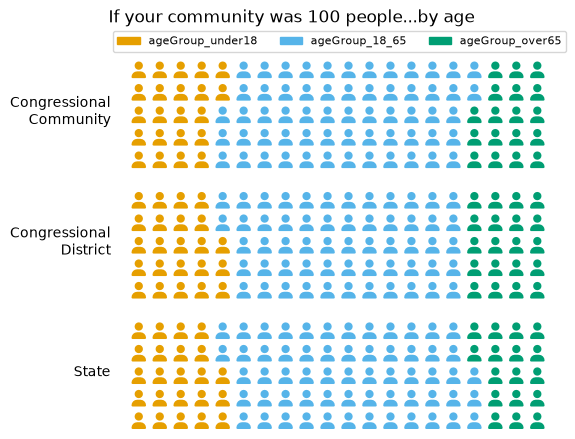

In [68]:
fig = make_full_chart(df_cc_graph, df_cd_graph, df_state_graph)

In [95]:
def make_full_chart_cc(df_cc_graph):

    fig, ax1  = plt.subplots(1)


    ## cc
    Waffle.make_waffle(
        ax=ax1,
        rows=10,
        columns=10,
        values=exclude_key(df_cc_graph, 'Total Population'),
        legend={'loc':'lower center', 'bbox_to_anchor': (0.5, 1), 
                            'ncol':3, 'fontsize':8},
                    starting_location='NW',
        icons='user',
        font_size=12, 
        colors = okabe_ito_colors[0:3]
    )


    fig.suptitle('If your community was 100 people...by age')
    plt.savefig('./figures/age_comparisons_cc')
    plt.show()
    
    return plt


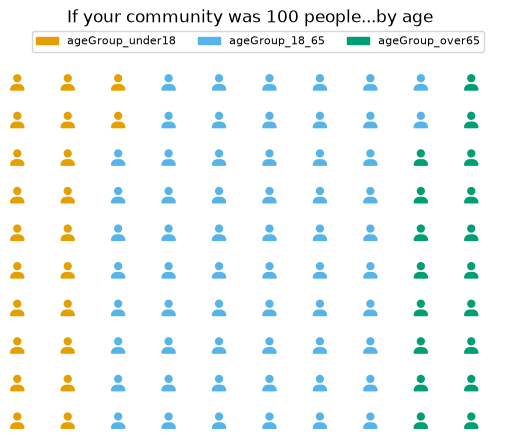

<module 'matplotlib.pyplot' from '/opt/anaconda3/envs/cc/lib/python3.13/site-packages/matplotlib/pyplot.py'>

In [96]:
make_full_chart_cc(df_cc_graph)

+ If it might be better to do just cc and comparisons

In [69]:
def make_group_chart(df_cc_graph): 
        fig, (ax1, ax2, ax3) = plt.subplots(3, sharex=True)

        not_used = "lightgrey"
        
        vals = exclude_key(df_cc_graph, 'Total Population')

        ## under 18
        Waffle.make_waffle(
        ax=ax1,
        rows=5,
        columns=20,
        values=vals,
        legend={'loc':'lower center', 'bbox_to_anchor': (0.5, 1), 
                                'ncol':3, 'fontsize':8},
                        starting_location='NW',
        icons='user',
        font_size=12, 
        colors = [okabe_ito_colors[0]] + [not_used]  + [not_used]
        )

        ## 18-64
        Waffle.make_waffle(
        ax=ax2,
        rows=5,
        columns=20,
        values=vals,
        legend={'loc':'lower center', 'bbox_to_anchor': (0.5, 1), 
                                'ncol':3, 'fontsize':8},
                        starting_location='NW',
        icons='user',
        font_size=12, 
        colors = [not_used] + [okabe_ito_colors[1]] + [not_used]
        )

        ## s65+ 
        Waffle.make_waffle(
        ax=ax3,
        rows=5,
        columns=20,
        values=vals,
        legend={'loc':'lower center', 'bbox_to_anchor': (0.5, 1), 
                                'ncol':3, 'fontsize':8},
                        starting_location='NW',
        icons='user',
        font_size=12, 
        colors = [not_used] + [not_used] + [okabe_ito_colors[2]] 
        )


        ax1.text(-0.05, 0.5, 'Under 18', transform=ax1.transAxes,
                fontsize=10, ha='right', va='center', rotation=0)
        ax2.text(-0.05, 0.5, '18-64', transform=ax2.transAxes,
                fontsize=10, ha='right', va='center', rotation=0)
        ax3.text(-0.05, 0.5, '65 and over', transform=ax3.transAxes,
                fontsize=10, ha='right', va='center', rotation=0)

        plt.subplots_adjust(left=0.25)  # make room so labels aren't cut off

        # Remove legends from ax2 and ax3, keep only ax1's
        ax1.get_legend().remove()
        ax2.get_legend().remove()
        ax3.get_legend().remove()

        fig.suptitle('If your community was 100 people...by age')
        plt.savefig('./figures/age_groups')

        return fig


In [70]:
# making function to just make the groups for cc 
# now making graph that combines them 

def make_chart_group_ind(vals, age_bracket_cols, group_no, label_map=None):
    # calculating variables 
    not_used = "lightgrey"
    num_groups = len(age_bracket_cols) 
    
    # default mapping from raw column names to readable legend labels
    if label_map is None:
        label_map = {
            'ageGroup_under18': 'Under 18',
            'ageGroup_18_65': '18 to 65',
            'ageGroup_over65': '65 and over',
        }
    readable_labels = [label_map.get(k, k) for k in vals.keys()]
    
    # changing color list 
    color_list = [not_used] * num_groups
    color_list[group_no] = okabe_ito_colors[group_no]

    ## plotting cc 
    plt.figure(
        FigureClass=Waffle,
        rows=5,
        columns=20,
        values=vals,
        labels=readable_labels,   # overrides legend text
        legend={'loc': 'upper left', 'bbox_to_anchor': (1.1, 1)},
        icons='user',
        font_size=12, 
        colors = color_list, 
        interval_ratio_x=0.6,
        interval_ratio_y=1, 
    )
    

    plt.savefig(f'./figures/age_comparisons_ind_group{group_no}.png')
    plt.show()
    
    return plt


In [71]:
def generate_ind_charts(df_cc_graph, age_bracket_cols):
    vals = exclude_key(df_cc_graph, 'Total Population')
    for group_no in range(len(age_bracket_cols)):
        make_chart_group_ind(vals, age_bracket_cols, group_no)

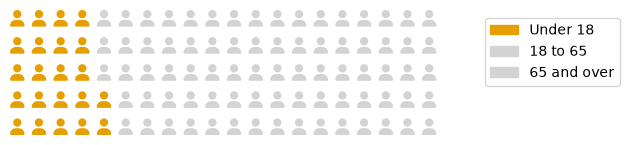

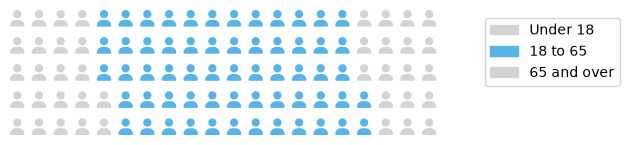

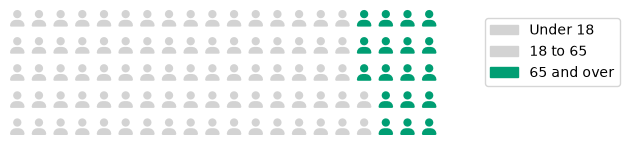

In [72]:
generate_ind_charts(df_cc_graph, age_bracket_cols)

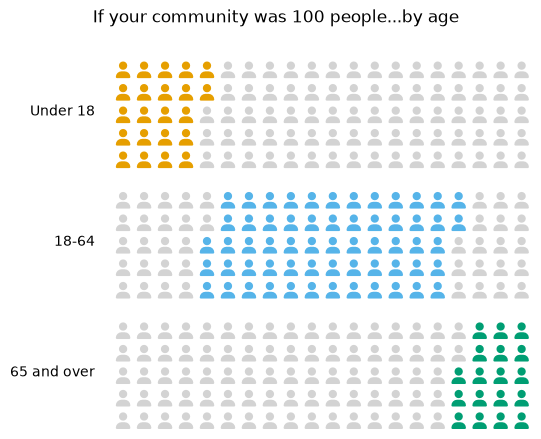

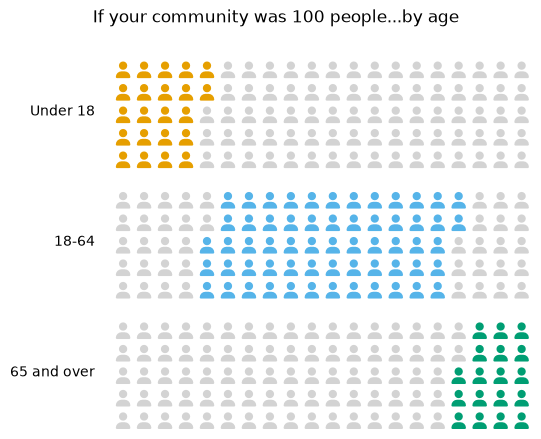

In [73]:
make_group_chart(df_cc_graph)

# Making compoarison charts

In [74]:
def floor_to_decimals(value, decimals=0):
    factor = 10 ** decimals
    return math.floor(value * factor) / factor

def ceil_to_decimals(value, decimals=0):
    factor = 10 ** decimals
    return math.ceil(value * factor) / factor

+ making them into one plot

In [75]:
import plotly.graph_objects as go
import numpy as np

def make_line_comp_chart_plotly(age_group_label):
    not_used = lighter_ito_colors[age_bracket_cols.index(age_group_label)]
    color_used = okabe_ito_colors[age_bracket_cols.index(age_group_label)]

    # number line ticks
    intervals = np.round(np.linspace(0, 1, 11), 2)

    # calculate % for each group
    x_cc = df_state_graph[ccn20_record['State']][age_group_label] / df_state_graph[ccn20_record['State']]['Total Population']
    x_cd = df_cd_graph[ccn20_record['DC']][age_group_label] / df_cd_graph[ccn20_record['DC']]['Total Population']
    x_state = df_cc_graph[age_group_label] / df_cc_graph['Total Population']

    fig = go.Figure()

    # baseline number line (tick marks along y=1)
    fig.add_trace(go.Scatter(
        x=intervals, y=[1] * len(intervals),
        mode='lines+markers',
        marker=dict(symbol='line-ns', size=10, color='lightgrey', line=dict(width=1)),
        opacity=0.5,
        hoverinfo='skip',
        showlegend=False
    ))

    # State
    fig.add_trace(go.Scatter(
        x=[x_state], y=[1],
        mode='markers',
        marker=dict(symbol='diamond-x', size=20, color=not_used,
                    line=dict(color='white', width=2)),
        name='State',
        hovertemplate=f"State: {x_state:.1%}<extra></extra>"
    ))

    # Congressional District
    fig.add_trace(go.Scatter(
        x=[x_cd], y=[1],
        mode='markers',
        marker=dict(symbol='circle', size=20, color=not_used,
                    line=dict(color='white', width=2)),
        name='Congressional District',
        hovertemplate=f"Congressional District: {x_cd:.1%}<extra></extra>"
    ))

    # Congressional Community (highlighted color)
    fig.add_trace(go.Scatter(
        x=[x_cc], y=[1],
        mode='markers',
        marker=dict(symbol='circle', size=20, color=color_used,
                    line=dict(color='white', width=2)),
        name='Congressional Community',
        hovertemplate=f"Congressional Community: {x_cc:.1%}<extra></extra>"
    ))

    # dynamically adjust x range
    x_min = floor_to_decimals(min(x_cc, x_cd, x_state), 1) - 0.01
    x_max = ceil_to_decimals(max(x_cc, x_cd, x_state), 2) + 0.07

    fig.update_layout(
        xaxis=dict(
            range=[x_min, x_max],
            tickmode='array',
            tickvals=intervals,
            ticktext=[f"{round(v * 100)}%" for v in intervals],
            showgrid=False,
            zeroline=False, 
            color='lightgrey'
        ),
        yaxis=dict(visible=False, range=[0.9, 1.1]),
        legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='center', x=0.5),
        height=200,
        margin=dict(l=20, r=20, t=40, b=40),
        plot_bgcolor='white'
    )
    
    fig.write_html(
    f'./figures/age_comparisons_line_plotly_{age_group_label}.html',
    include_plotlyjs="cdn",     # loads plotly.js from CDN — keeps file size small
    full_html=True,             # standalone <html> doc, not just a <div> snippet
    config={
        "displayModeBar": False,   # hide the toolbar (camera/zoom icons) for a cleaner embed
        "responsive": True         # resize with the iframe/container automatically
    }
)

    return fig

In [76]:
# for age_group_label in age_bracket_cols: make_line_comp_chart_plotly(age_group_label)

In [77]:
round(20.0)

20

In [78]:
fig_1 = make_line_comp_chart_plotly(age_bracket_cols[0])
fig_1

In [79]:
fig_2 = make_line_comp_chart_plotly(age_bracket_cols[1])
fig_2

In [80]:
fig_3 = make_line_comp_chart_plotly(age_bracket_cols[2])
fig_3

# Making it a widget to update on hover

In [81]:
import plotly.graph_objects as go
import numpy as np

def make_line_comp_chart_widget(age_group_label):
    not_used = lighter_ito_colors[age_bracket_cols.index(age_group_label)]
    color_used = okabe_ito_colors[age_bracket_cols.index(age_group_label)]

    # number line ticks
    intervals = np.round(np.linspace(0, 1, 11), 2)

    # calculate % for each group
    x_cc = df_state_graph[ccn20_record['State']][age_group_label] / df_state_graph[ccn20_record['State']]['Total Population']
    x_cd = df_cd_graph[ccn20_record['DC']][age_group_label] / df_cd_graph[ccn20_record['DC']]['Total Population']
    x_state = df_cc_graph[age_group_label] / df_cc_graph['Total Population']

    fig = go.Figure()

    # baseline number line (tick marks along y=1)
    fig.add_trace(go.Scatter(
        x=intervals, y=[1] * len(intervals),
        mode='lines+markers',
        marker=dict(symbol='line-ns', size=10, color='lightgrey', 
                    line=dict(width=1.5, color = 'lightgrey')),
        opacity=0.5,
        hoverinfo='skip',
        showlegend=False
    ))

    # State
    fig.add_trace(go.Scatter(
        x=[x_state], y=[1],
        mode='markers',
        marker=dict(symbol='diamond-x', size=20, color=not_used,
                    line=dict(color='white', width=2)),
        name='State',
        hovertemplate=f"State: {x_state:.1%}<extra></extra>"
    ))

    # Congressional District
    fig.add_trace(go.Scatter(
        x=[x_cd], y=[1],
        mode='markers',
        marker=dict(symbol='circle', size=20, color=not_used,
                    line=dict(color='white', width=2)),
        name='Congressional District',
        hovertemplate=f"Congressional District: {x_cd:.1%}<extra></extra>"
    ))

    # Congressional Community (highlighted color)
    fig.add_trace(go.Scatter(
        x=[x_cc], y=[1],
        mode='markers',
        marker=dict(symbol='circle', size=20, color=color_used,
                    line=dict(color='white', width=2)),
        name='Congressional Community',
        hovertemplate=f"Congressional Community: {x_cc:.1%}<extra></extra>"
    ))

    # dynamically adjust x range
    x_min = floor_to_decimals(min(x_cc, x_cd, x_state), 1) - 0.01
    x_max = ceil_to_decimals(max(x_cc, x_cd, x_state), 2) + 0.07

    fig.update_layout(
        xaxis=dict(
            range=[x_min, x_max],
            tickmode='array',
            tickvals=intervals,
            ticktext=[f"{round(v * 100)}%" for v in intervals],
            showgrid=False,
            zeroline=False,
            color='lightgrey'
        ),
        yaxis=dict(visible=False, range=[0.9, 1.1]),
        legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='center', x=0.5),
        height=200,
        margin=dict(l=20, r=20, t=40, b=40),
        plot_bgcolor='white'
    )
    fig_widget = go.FigureWidget(data=fig.data, layout=fig.layout)
    return fig_widget



In [82]:
fig_1_widget = make_line_comp_chart_widget(age_bracket_cols[0])
fig_2_widget = make_line_comp_chart_widget(age_bracket_cols[1])
fig_3_widget = make_line_comp_chart_widget(age_bracket_cols[2])

In [83]:
from ipywidgets import HBox, VBox
from ipywidgets.embed import embed_minimal_html

line_com_widget = VBox([fig_1_widget, fig_2_widget, fig_3_widget])
line_com_widget

    'data': [{'hoverinfo': 'skip',
              'marker': {'color': 'lightgrey'…

In [84]:
# make dashboard actually 

# put together the waffle charts and the line charts into a dashboard



In [91]:
df_age_indexed = df_age.set_index('CCN20')

age_cc_data = {}

for ccn20_number in set(df_age.CCN20):
    ccn20_record = ccn20_dict[ccn20_number][0]
    cc_row = df_age_indexed.loc[ccn20_number]

    age_cc_data[str(ccn20_number)] = {
        "age_brackets": age_bracket_cols,
        "cc": {col: int(cc_row[col]) for col in age_bracket_cols},
        "cc_total": int(cc_row['Total Population']),
        "cd": {col: int(df_cd_graph[ccn20_record['DC']][col]) for col in age_bracket_cols},
        "cd_total": int(df_cd_graph[ccn20_record['DC']]['Total Population']),
        "state": {col: int(df_state_graph[ccn20_record['State']][col]) for col in age_bracket_cols},
        "state_total": int(df_state_graph[ccn20_record['State']]['Total Population']),
    }

with open('./data/age_cc_data.json', 'w') as f:
    json.dump(age_cc_data, f)

+ builds static html

# map and selection